Load Libraries And Paths

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    from helper_functions import PROCESSED_DIR
except ImportError:
    PROJECT_ROOT = Path.cwd()

    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

CENTROID_DIR = PROCESSED_DIR / "03_ortools_centroids"
PLOTS_DIR = PROJECT_ROOT / "plots" / "centroid_overview"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR / "09_selected_genres_ortools"

CENTROID_DIR

PosixPath('/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/data/processed/03_ortools_centroids')

In [23]:
prefix = "ortools_top50_mintracks20_topcandidates5_genrepool180"
selected_genres_ORtools = PROCESSED_DIR / "01_selected_genres_ortools"
genre_window_coverage = pd.read_parquet(
    selected_genres_ORtools / f"{prefix}_genre_window_coverage.parquet"
)

Load Raw And Within-Period Normalized Centroids

In [24]:
modalities = [
    "essentia",
    "lyrics_tf_idf",
    "word2vec",
    "mfcc",
    "musicnn",
    "vgg19",
]

raw_centroids = {}
wpz_centroids = {}

for modality in modalities:
    raw_path = CENTROID_DIR / f"{modality}_ortools_centroids_raw_windowed.parquet"
    wpz_path = CENTROID_DIR / f"{modality}_ortools_centroids_wpz_windowed.parquet"

    raw_centroids[modality] = pd.read_parquet(raw_path)
    wpz_centroids[modality] = pd.read_parquet(wpz_path)

    print(modality)
    print("Raw:", raw_centroids[modality].shape)
    print("WPZ:", wpz_centroids[modality].shape)
    print()

essentia
Raw: (2198, 1042)
WPZ: (2198, 1042)

lyrics_tf_idf
Raw: (2198, 1008)
WPZ: (2198, 1008)

word2vec
Raw: (2198, 308)
WPZ: (2198, 308)

mfcc
Raw: (2198, 112)
WPZ: (2198, 112)

musicnn
Raw: (2198, 58)
WPZ: (2198, 58)

vgg19
Raw: (2119, 8200)
WPZ: (2119, 8200)



Basic Centroid File Overview

In [25]:
overview_rows = []

for modality in modalities:
    for representation, data in [
        ("raw", raw_centroids[modality]),
        ("within_period_z", wpz_centroids[modality]),
    ]:
        metadata_cols = {
            "genre",
            "modality",
            "window_start",
            "window_end",
            "window_label",
            "n_tracks",
            "mean_genre_score",
            "median_genre_score",
        }

        feature_columns = [
            column for column in data.columns
            if column not in metadata_cols
        ]

        overview_rows.append({
            "modality": modality,
            "representation": representation,
            "n_centroids": len(data),
            "n_genres": data["genre"].nunique(),
            "n_windows": data["window_start"].nunique(),
            "min_window_start": data["window_start"].min(),
            "max_window_start": data["window_start"].max(),
            "n_feature_columns": len(feature_columns),
            "min_tracks": data["n_tracks"].min(),
            "median_tracks": data["n_tracks"].median(),
            "mean_tracks": data["n_tracks"].mean(),
            "max_tracks": data["n_tracks"].max(),
        })

centroid_overview = pd.DataFrame(overview_rows)
centroid_overview

,modality,representation,n_centroids,n_genres,n_windows,min_window_start,max_window_start,n_feature_columns,min_tracks,median_tracks,mean_tracks,max_tracks
0,essentia,raw,2198,50,61,1955,2015,1034,20,90.0,193.603731,3840
1,essentia,within_period_z,2198,50,61,1955,2015,1034,20,90.0,193.603731,3840
2,lyrics_tf_idf,raw,2198,50,61,1955,2015,1000,20,90.0,193.761146,3846
3,lyrics_tf_idf,within_period_z,2198,50,61,1955,2015,1000,20,90.0,193.761146,3846
4,word2vec,raw,2198,50,61,1955,2015,300,20,90.0,193.761146,3846
5,word2vec,within_period_z,2198,50,61,1955,2015,300,20,90.0,193.761146,3846
6,mfcc,raw,2198,50,61,1955,2015,104,20,90.0,193.761146,3846
7,mfcc,within_period_z,2198,50,61,1955,2015,104,20,90.0,193.761146,3846
8,musicnn,raw,2198,50,61,1955,2015,50,20,90.0,193.758872,3846
9,musicnn,within_period_z,2198,50,61,1955,2015,50,20,90.0,193.758872,3846


Check Selected Genres Per Modality

In [26]:
genre_counts = []

for modality in modalities:
    data = raw_centroids[modality]

    genre_counts.append({
        "modality": modality,
        "n_genres": data["genre"].nunique(),
        "genres": sorted(data["genre"].unique()),
    })

genre_counts = pd.DataFrame(genre_counts)
genre_counts[["modality", "n_genres"]]

,modality,n_genres
0,essentia,50
1,lyrics_tf_idf,50
2,word2vec,50
3,mfcc,50
4,musicnn,50
5,vgg19,50


Centroid Availability By Window

In [27]:
window_availability = []

for modality in modalities:
    data = raw_centroids[modality]

    summary = (
        data
        .groupby("window_start")
        .agg(
            n_genres=("genre", "nunique"),
            n_centroids=("genre", "size"),
            median_tracks=("n_tracks", "median"),
            mean_tracks=("n_tracks", "mean"),
        )
        .reset_index()
    )

    summary["modality"] = modality
    window_availability.append(summary)

window_availability = pd.concat(window_availability, ignore_index=True)
window_availability.head()

,window_start,n_genres,n_centroids,median_tracks,mean_tracks,modality
0,1955,6,6,24.5,52.166667,essentia
1,1956,6,6,29.5,56.333333,essentia
2,1957,6,6,35.0,52.166667,essentia
3,1958,6,6,35.0,48.333333,essentia
4,1959,9,9,29.0,38.444444,essentia


Plot Number Of Available Genre Centroids Over Time

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/centroid_overview/available_genre_centroids_per_window.png


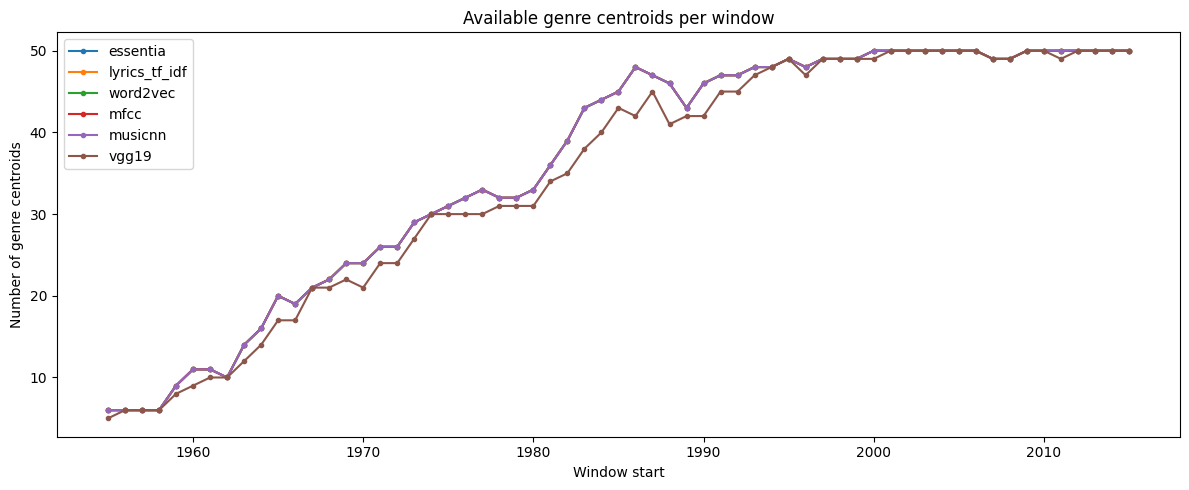

In [28]:
plt.figure(figsize=(12, 5))

for modality in modalities:
    data = window_availability[
        window_availability["modality"] == modality
    ]

    plt.plot(
        data["window_start"],
        data["n_genres"],
        marker="o",
        markersize=3,
        label=modality,
    )

plt.xlabel("Window start")
plt.ylabel("Number of genre centroids")
plt.title("Available genre centroids per window")
plt.legend()
plt.tight_layout()

output_path = PLOTS_DIR / "available_genre_centroids_per_window.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

Plot Median Tracks Per Centroid Over Time

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/centroid_overview/median_tracks_per_centroid_over_time.png


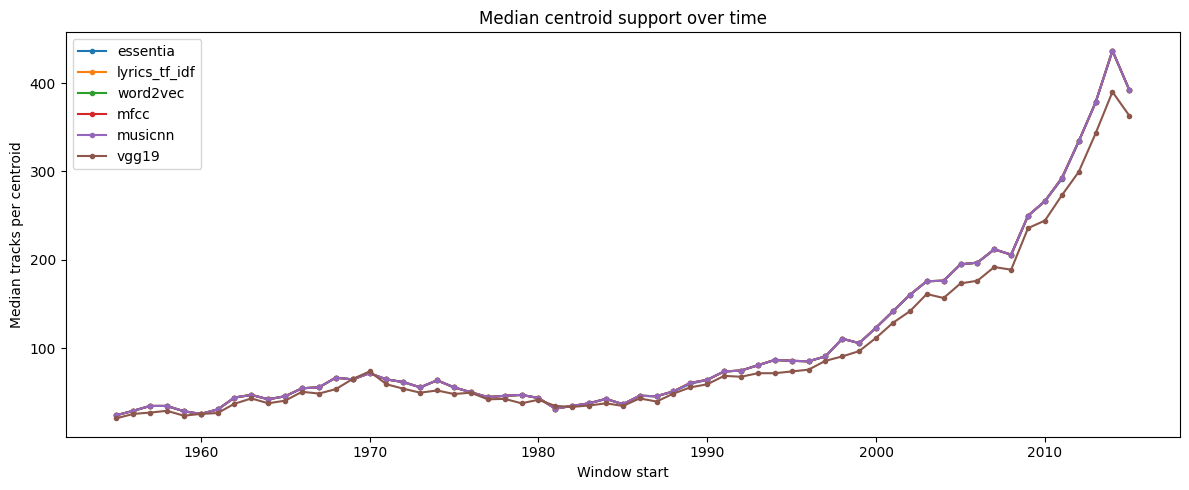

In [29]:
plt.figure(figsize=(12, 5))

for modality in modalities:
    data = window_availability[
        window_availability["modality"] == modality
    ]

    plt.plot(
        data["window_start"],
        data["median_tracks"],
        marker="o",
        markersize=3,
        label=modality,
    )

plt.xlabel("Window start")
plt.ylabel("Median tracks per centroid")
plt.title("Median centroid support over time")
plt.legend()
plt.tight_layout()

output_path = PLOTS_DIR / "median_tracks_per_centroid_over_time.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

Heatmap Of Centroid Availability By Genre And Window

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/centroid_overview/centroid_availability_word2vec.png


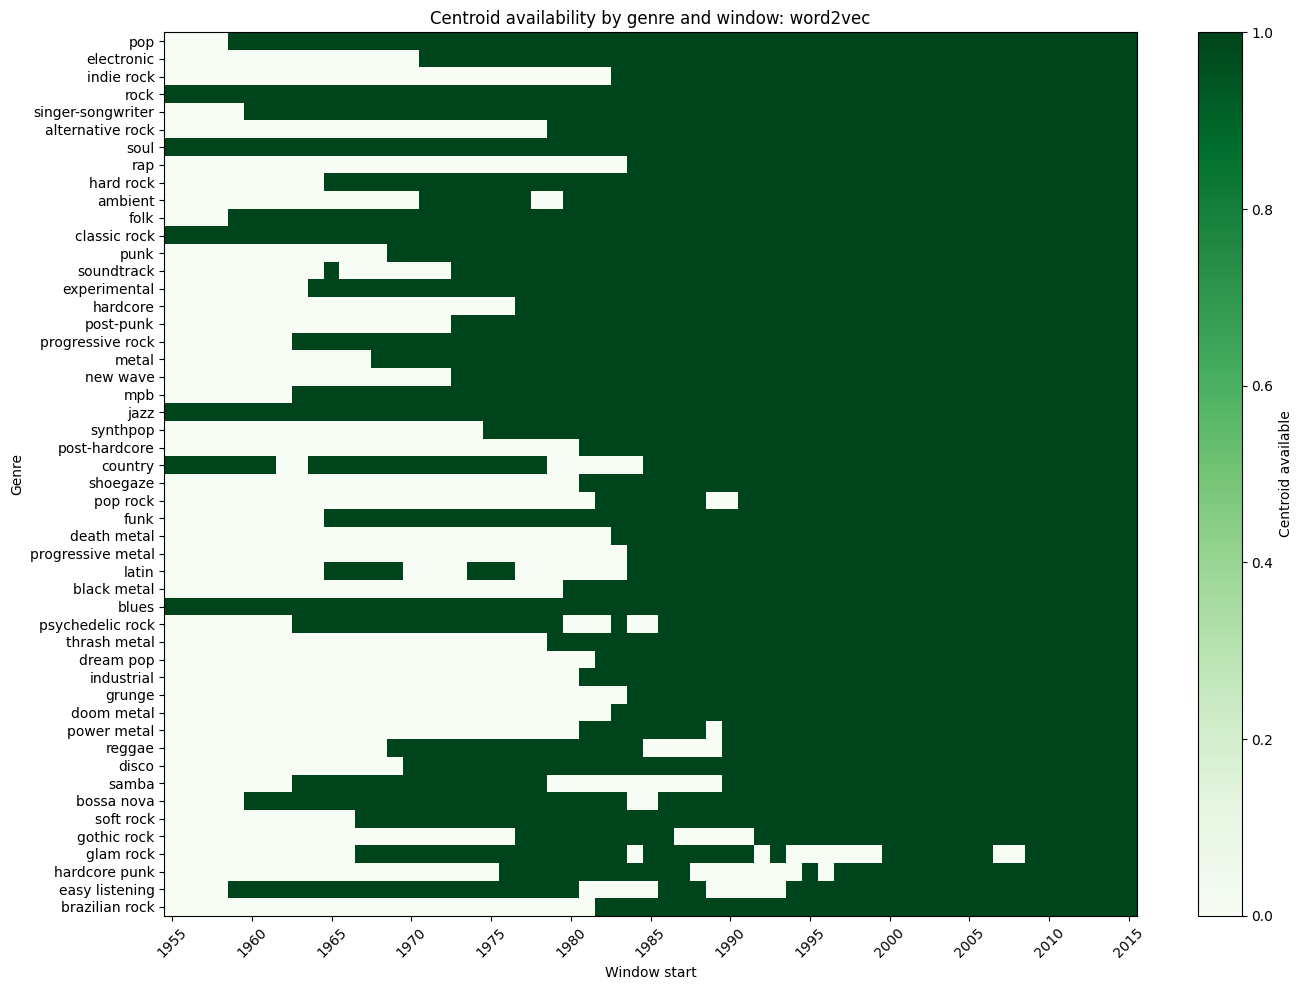

In [30]:
selected_modality = "word2vec"

data = raw_centroids[selected_modality].copy()

matrix_data = data.pivot_table(
    index="genre",
    columns="window_start",
    values="n_tracks",
    aggfunc="max",
    fill_value=0,
)

matrix_data = matrix_data.loc[
    matrix_data.sum(axis=1).sort_values(ascending=False).index
]

availability_matrix = (matrix_data > 0).astype(int)

plt.figure(figsize=(14, 10))
plt.imshow(
    availability_matrix.to_numpy(),
    aspect="auto",
    cmap="Greens",
    vmin=0,
    vmax=1,
)

plt.yticks(range(len(availability_matrix.index)), availability_matrix.index)
plt.xticks(
    range(0, len(availability_matrix.columns), 5),
    availability_matrix.columns[::5],
    rotation=45,
)

plt.xlabel("Window start")
plt.ylabel("Genre")
plt.title(f"Centroid availability by genre and window: {selected_modality}")
plt.colorbar(label="Centroid available")
plt.tight_layout()

output_path = PLOTS_DIR / f"centroid_availability_{selected_modality}.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

Heatmap Of Track Counts Behind Centroids

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/centroid_overview/centroid_track_counts_word2vec.png


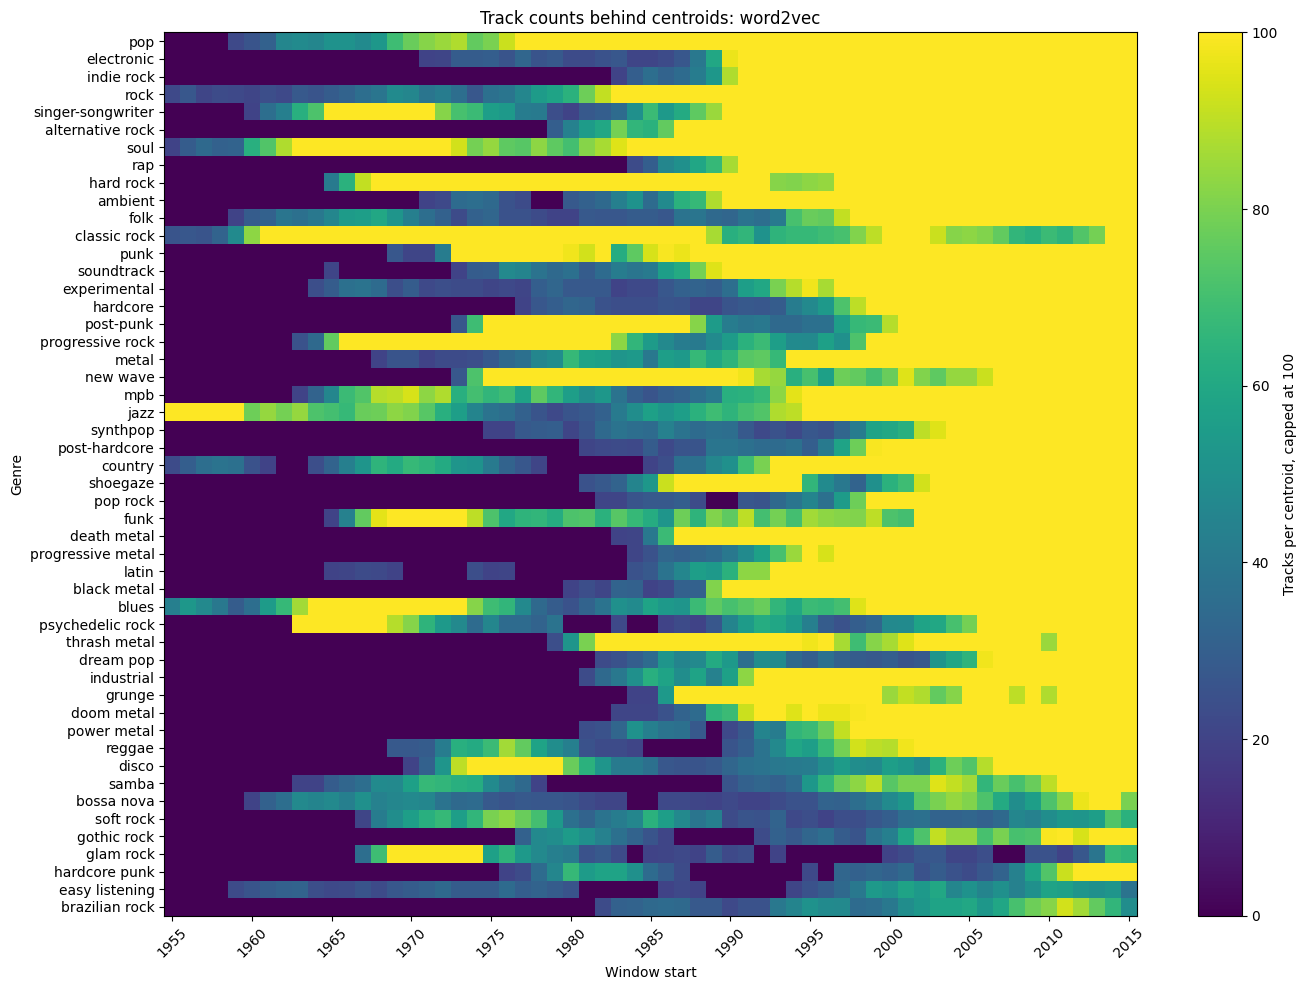

In [31]:
selected_modality = "word2vec"

data = raw_centroids[selected_modality].copy()

matrix_data = data.pivot_table(
    index="genre",
    columns="window_start",
    values="n_tracks",
    aggfunc="max",
    fill_value=0,
)

matrix_data = matrix_data.loc[
    matrix_data.sum(axis=1).sort_values(ascending=False).index
]

plt.figure(figsize=(14, 10))
plt.imshow(
    matrix_data.clip(upper=100).to_numpy(),
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=100,
)

plt.yticks(range(len(matrix_data.index)), matrix_data.index)
plt.xticks(
    range(0, len(matrix_data.columns), 5),
    matrix_data.columns[::5],
    rotation=45,
)

plt.xlabel("Window start")
plt.ylabel("Genre")
plt.title(f"Track counts behind centroids: {selected_modality}")
plt.colorbar(label="Tracks per centroid, capped at 100")
plt.tight_layout()

output_path = PLOTS_DIR / f"centroid_track_counts_{selected_modality}.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

Inspect Feature Columns Per Modality

In [32]:
feature_overview = []

metadata_cols = {
    "genre",
    "modality",
    "window_start",
    "window_end",
    "window_label",
    "n_tracks",
    "mean_genre_score",
    "median_genre_score",
}

for modality in modalities:
    data = raw_centroids[modality]

    feature_columns = [
        column for column in data.columns
        if column not in metadata_cols
    ]

    feature_overview.append({
        "modality": modality,
        "n_features": len(feature_columns),
        "first_features": feature_columns[:10],
    })

feature_overview = pd.DataFrame(feature_overview)
feature_overview

,modality,n_features,first_features
0,essentia,1034,"[lowlevel.average_loudness, lowlevel.barkbands..."
1,lyrics_tf_idf,1000,"[abl, accept, across, act, addict, afraid, age..."
2,word2vec,300,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
3,mfcc,104,"[MFCC000, MFCC001, MFCC002, MFCC003, MFCC004, ..."
4,musicnn,50,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
5,vgg19,8192,"[max0000, max0001, max0002, max0003, max0004, ..."


In [33]:
essentia_features = feature_overview[feature_overview["modality"] == "essentia"]
for feature in essentia_features["first_features"]:
    print(feature)

['lowlevel.average_loudness', 'lowlevel.barkbands.mean_0', 'lowlevel.barkbands.mean_1', 'lowlevel.barkbands.mean_2', 'lowlevel.barkbands.mean_3', 'lowlevel.barkbands.mean_4', 'lowlevel.barkbands.mean_5', 'lowlevel.barkbands.mean_6', 'lowlevel.barkbands.mean_7', 'lowlevel.barkbands.mean_8']


Raw Feature Trajectories For Selected Interpretable Features

In [34]:
selected_modality = "essentia"

candidate_features = [
    "lowlevel.average_loudness",
    "lowlevel.barkbands.mean_0",
]

data = raw_centroids[selected_modality].copy()

available_features = [
    feature for feature in candidate_features
    if feature in data.columns
]

available_features

['lowlevel.average_loudness', 'lowlevel.barkbands.mean_0']

Plot Raw Feature Trajectories By Genre

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/centroid_overview/raw_trajectory_essentia_lowlevel.average_loudness.png


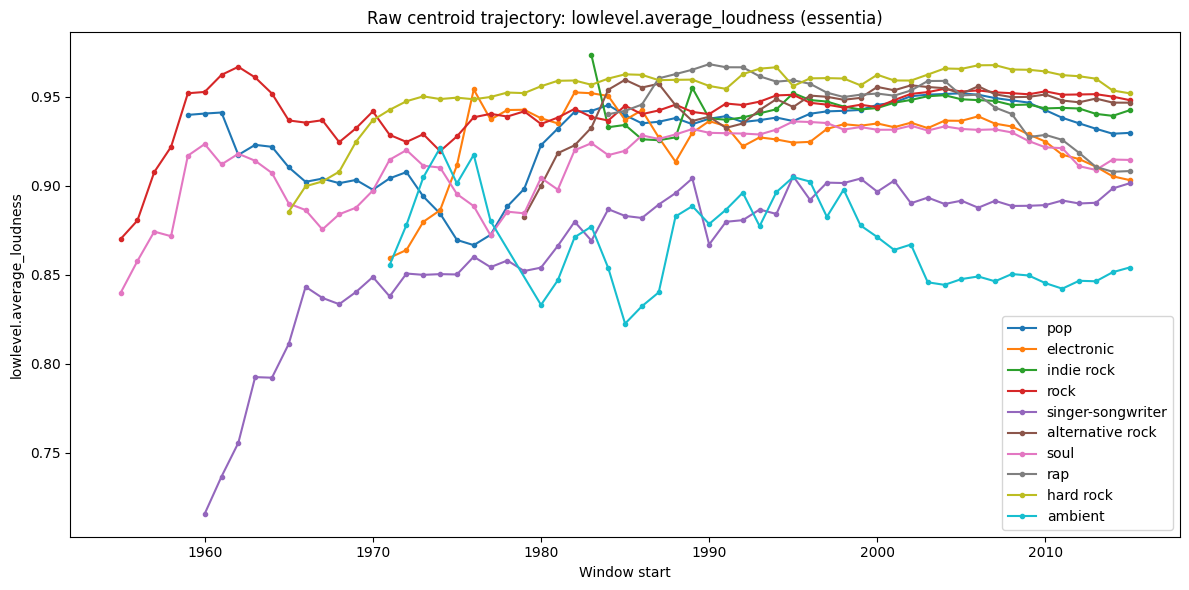

In [35]:
selected_modality = "essentia"
selected_feature = available_features[0]
top_n_genres = 10

data = raw_centroids[selected_modality].copy()

top_genres = (
    data
    .groupby("genre")["n_tracks"]
    .sum()
    .sort_values(ascending=False)
    .head(top_n_genres)
    .index
)

plt.figure(figsize=(12, 6))

for genre in top_genres:
    genre_data = data[data["genre"] == genre].sort_values("window_start")

    plt.plot(
        genre_data["window_start"],
        genre_data[selected_feature],
        marker="o",
        markersize=3,
        label=genre,
    )

plt.xlabel("Window start")
plt.ylabel(selected_feature)
plt.title(f"Raw centroid trajectory: {selected_feature} ({selected_modality})")
plt.legend()
plt.tight_layout()

output_path = PLOTS_DIR / f"raw_trajectory_{selected_modality}_{selected_feature}.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

### Track Counts For Centroid-Eligible Genre-Windows

In [36]:
genre_window_coverage

,modality,genre,window_start,window_end,window_label,n_tracks,mean_genre_score,median_genre_score,eligible_window
0,essentia,blues,1955,1959,1955_1959,43,2.673721,2.625,True
1,essentia,bossa nova,1955,1959,1955_1959,1,1.991000,1.991,False
2,essentia,classic rock,1955,1959,1955_1959,26,2.712923,1.978,True
3,essentia,country,1955,1959,1955_1959,23,4.520261,5.113,True
4,essentia,easy listening,1955,1959,1955_1959,9,2.891778,2.169,False
...,...,...,...,...,...,...,...,...,...
15027,word2vec,soft rock,2015,2019,2015_2019,64,2.654016,2.098,True
15028,word2vec,soul,2015,2019,2015_2019,1070,2.566829,1.998,True
15029,word2vec,soundtrack,2015,2019,2015_2019,480,3.093627,2.394,True
15030,word2vec,synthpop,2015,2019,2015_2019,947,2.123211,1.528,True


In [37]:
eligible_genre_windows = genre_window_coverage[
    genre_window_coverage["eligible_window"]
]

eligible_genre_windows["n_tracks"].describe()

count    13109.00000
mean       191.61637
std        309.04561
min         20.00000
25%         41.00000
50%         89.00000
75%        212.00000
max       3846.00000
Name: n_tracks, dtype: float64

### Track Counts By Modality

In [38]:
genre_window_coverage.groupby("modality")["n_tracks"].describe()

,count,mean,std,min,25%,50%,75%,max
modality,,,,,,,,
essentia,2508.0,170.639553,298.343195,1.0,30.0,72.5,188.0,3840.0
lyrics_tf_idf,2508.0,170.778708,298.670283,1.0,30.0,72.5,188.0,3846.0
mfcc,2508.0,170.778708,298.670283,1.0,30.0,72.5,188.0,3846.0
musicnn,2508.0,170.776715,298.666900,1.0,30.0,72.5,188.0,3846.0
vgg19,2492.0,154.897673,276.436216,1.0,26.0,65.0,169.0,3556.0
word2vec,2508.0,170.778708,298.670283,1.0,30.0,72.5,188.0,3846.0


### Track Count Distribution By Modality

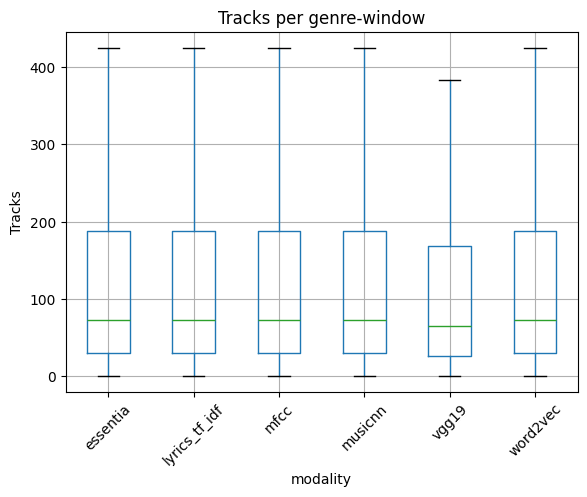

In [39]:
genre_window_coverage.boxplot(
    column="n_tracks",
    by="modality",
    rot=45,
    showfliers=False
)
plt.title("Tracks per genre-window")
plt.suptitle("")
plt.ylabel("Tracks")
plt.show()

In [40]:
window_coverage = (
    genre_window_coverage
    .groupby(["modality", "window_start", "window_end"])
    .agg(
        n_valid_genres_centroid=("eligible_window", "sum"),
        n_genres_observed=("genre", "nunique"),
        n_tracks=("n_tracks", "sum"),
    )
    .reset_index()
)

### Valid Genres Heatmap By Modality And Window

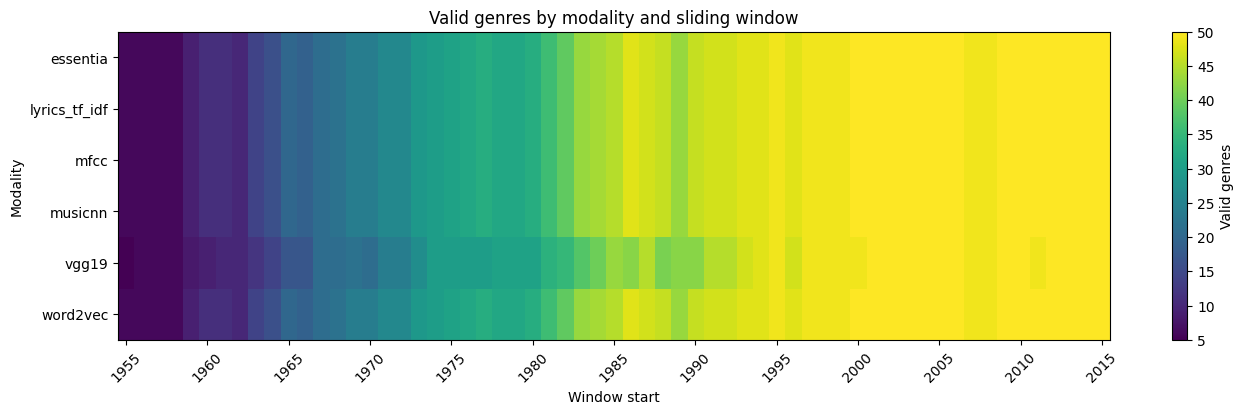

In [41]:
valid_genre_pivot = window_coverage.pivot(
    index="modality",
    columns="window_start",
    values="n_valid_genres_centroid"
)

plt.figure(figsize=(16, 4))
plt.imshow(valid_genre_pivot, aspect="auto", cmap="viridis")

plt.yticks(
    range(len(valid_genre_pivot.index)),
    valid_genre_pivot.index
)
plt.xticks(
    range(0, len(valid_genre_pivot.columns), 5),
    valid_genre_pivot.columns[::5],
    rotation=45
)

plt.colorbar(label="Valid genres")
plt.xlabel("Window start")
plt.ylabel("Modality")
plt.title("Valid genres by modality and sliding window")
plt.show()

### Top Genres By Eligible Windows

In [42]:
genre_availability = (
    genre_window_coverage
    .groupby(["modality", "genre"])
    .agg(
        n_centroid_eligible_windows=("eligible_window", "sum"),
        n_windows_observed=("window_start", "nunique"),
        n_tracks_total=("n_tracks", "sum"),
        median_tracks_per_window=("n_tracks", "median"),
        mean_tracks_per_window=("n_tracks", "mean"),
    )
    .reset_index()
)

genre_availability.head()

,modality,genre,n_centroid_eligible_windows,n_windows_observed,n_tracks_total,median_tracks_per_window,mean_tracks_per_window
0,essentia,alternative rock,37,40,15735,440.0,393.375000
1,essentia,ambient,43,50,11754,133.0,235.080000
2,essentia,black metal,36,44,5678,124.0,129.045455
3,essentia,blues,61,61,5607,77.0,91.918033
4,essentia,bossa nova,54,61,2439,34.0,39.983607


In [43]:
top_genres = (
    genre_availability
    .sort_values(
        ["modality", "n_centroid_eligible_windows", "n_tracks_total"],
        ascending=[True, False, False],
    )
    .groupby("modality")
    .head(15)
)

top_genres[
    [
        "modality",
        "genre",
        "n_centroid_eligible_windows",
        "n_windows_observed",
        "n_tracks_total",
        "median_tracks_per_window",
    ]
]

,modality,genre,n_centroid_eligible_windows,n_windows_observed,n_tracks_total,median_tracks_per_window
41,essentia,rock,61,61,17952,163.0
46,essentia,soul,61,61,14644,149.0
6,essentia,classic rock,61,61,10767,101.0
25,essentia,jazz,61,61,7314,83.0
3,essentia,blues,61,61,5607,77.0
...,...,...,...,...,...,...
278,word2vec,mpb,53,60,7435,71.5
257,word2vec,country,53,61,6826,52.0
264,word2vec,experimental,52,54,9297,36.5
270,word2vec,hard rock,51,56,12454,259.0


In [44]:
genre_window_coverage[
    (genre_window_coverage["modality"] == "essentia")
    & (genre_window_coverage["genre"] == "soul")
    & (genre_window_coverage["window_start"] == 1960)
][
    ["modality", "genre", "window_start", "window_end", "n_tracks", "eligible_window"]
]

,modality,genre,window_start,window_end,n_tracks,eligible_window
82,essentia,soul,1960,1964,63,True


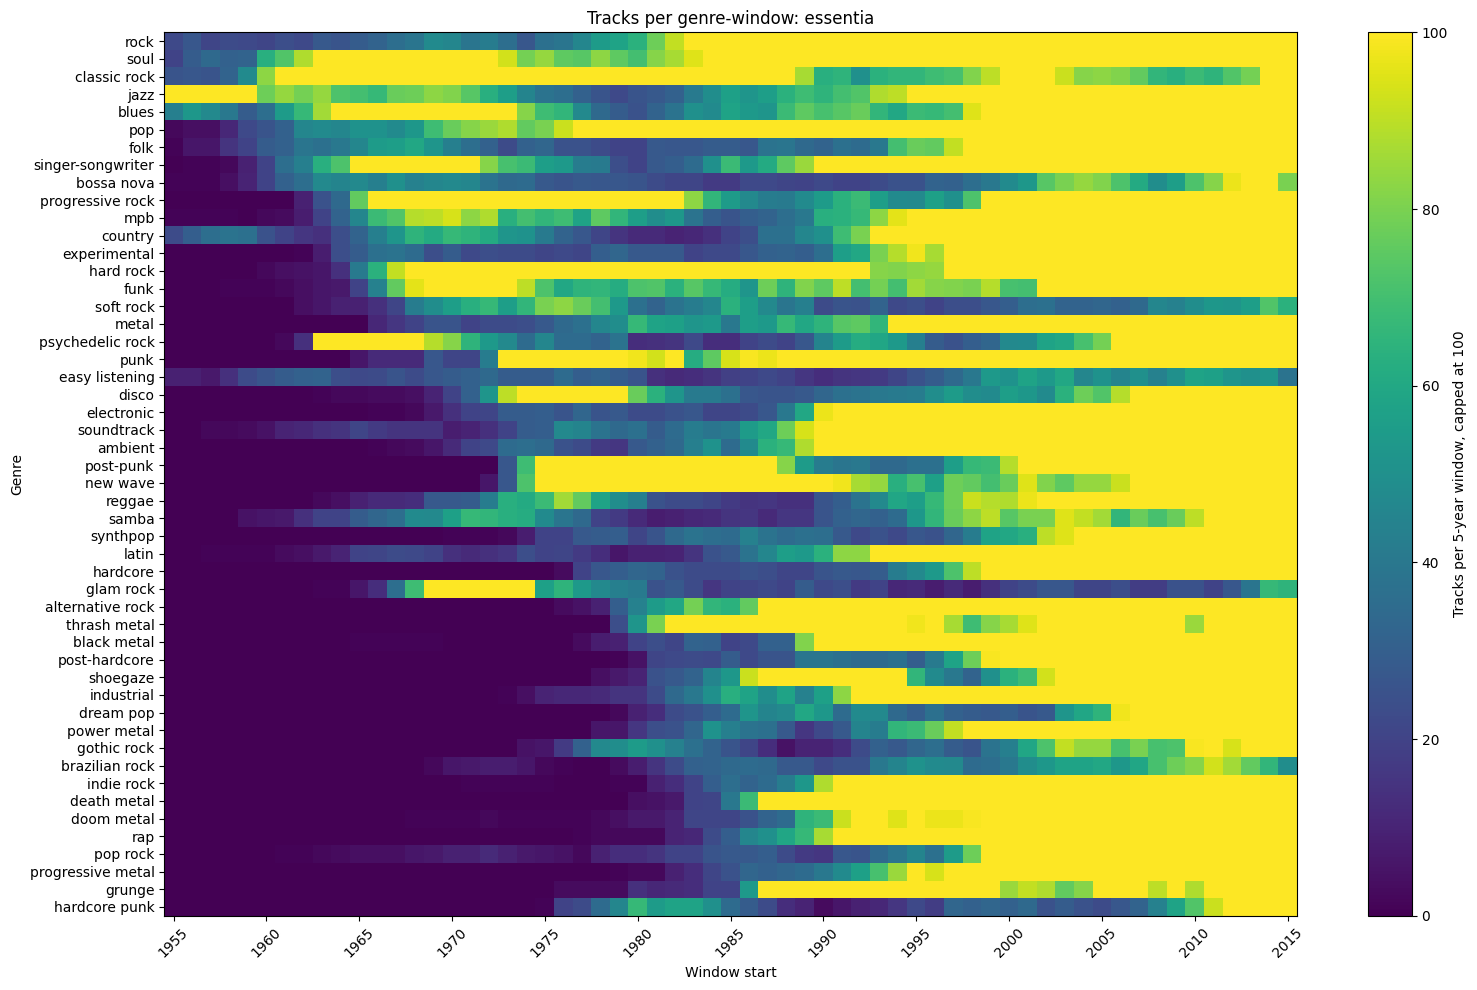

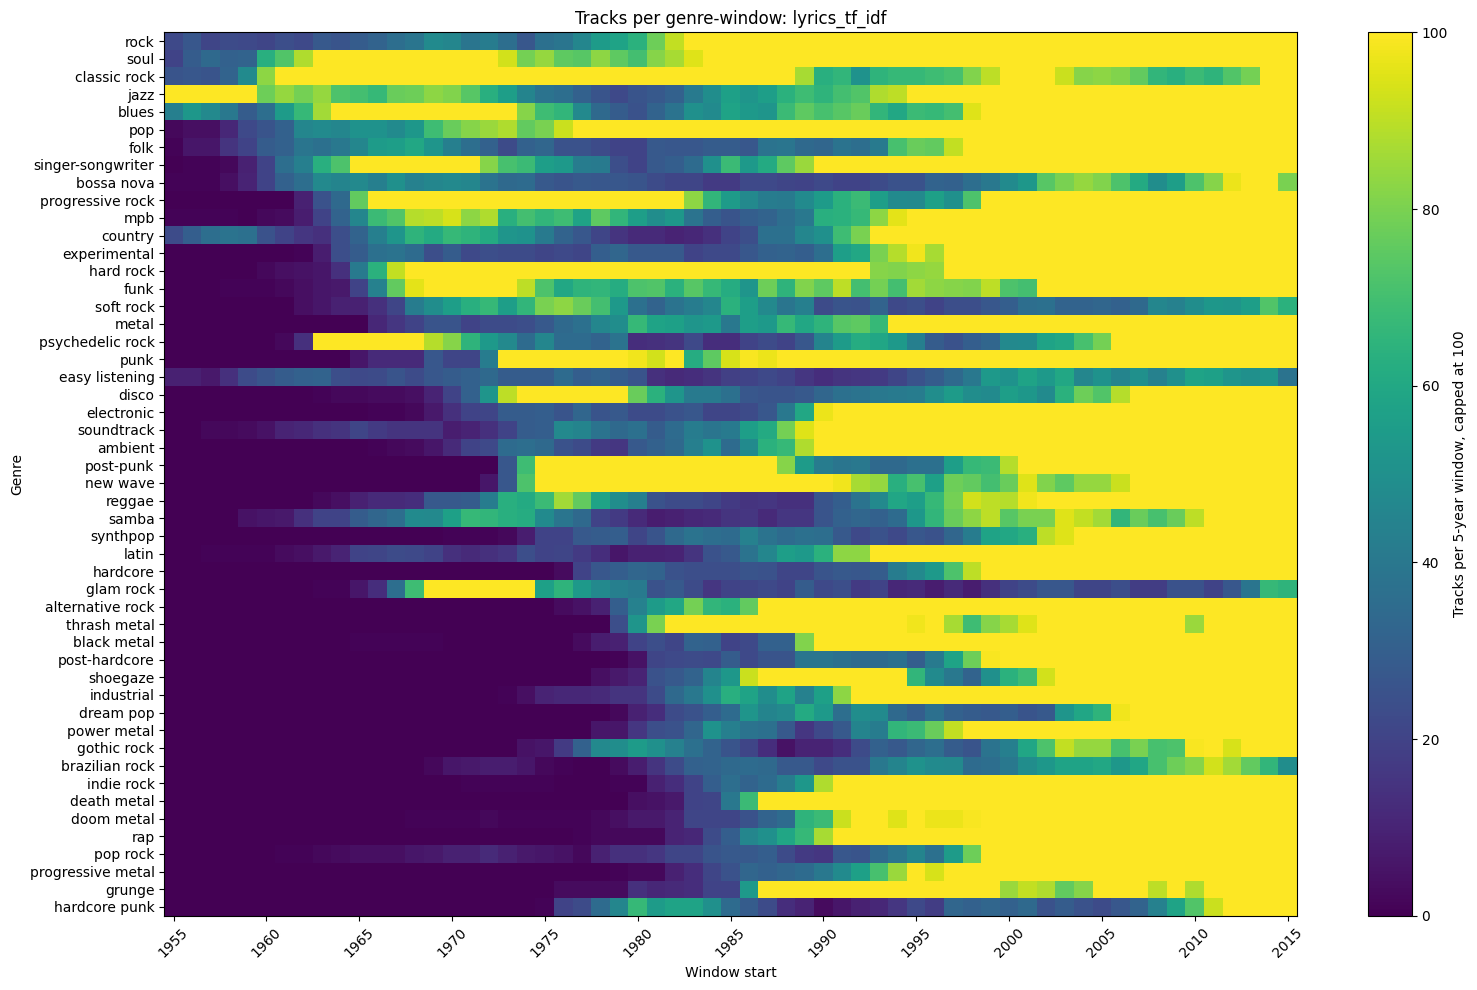

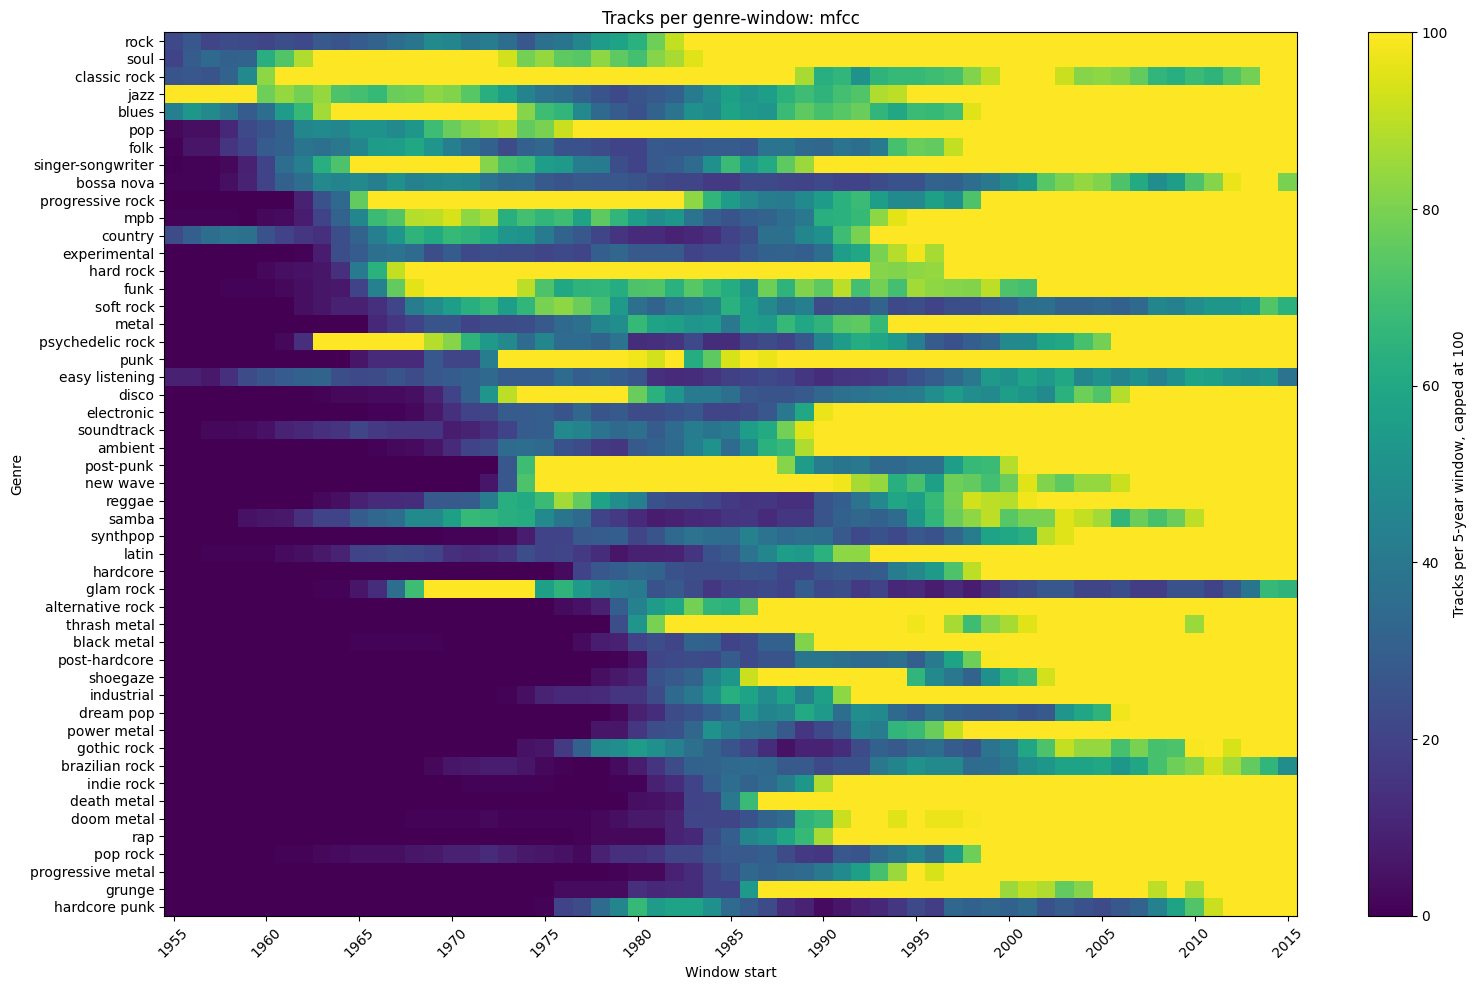

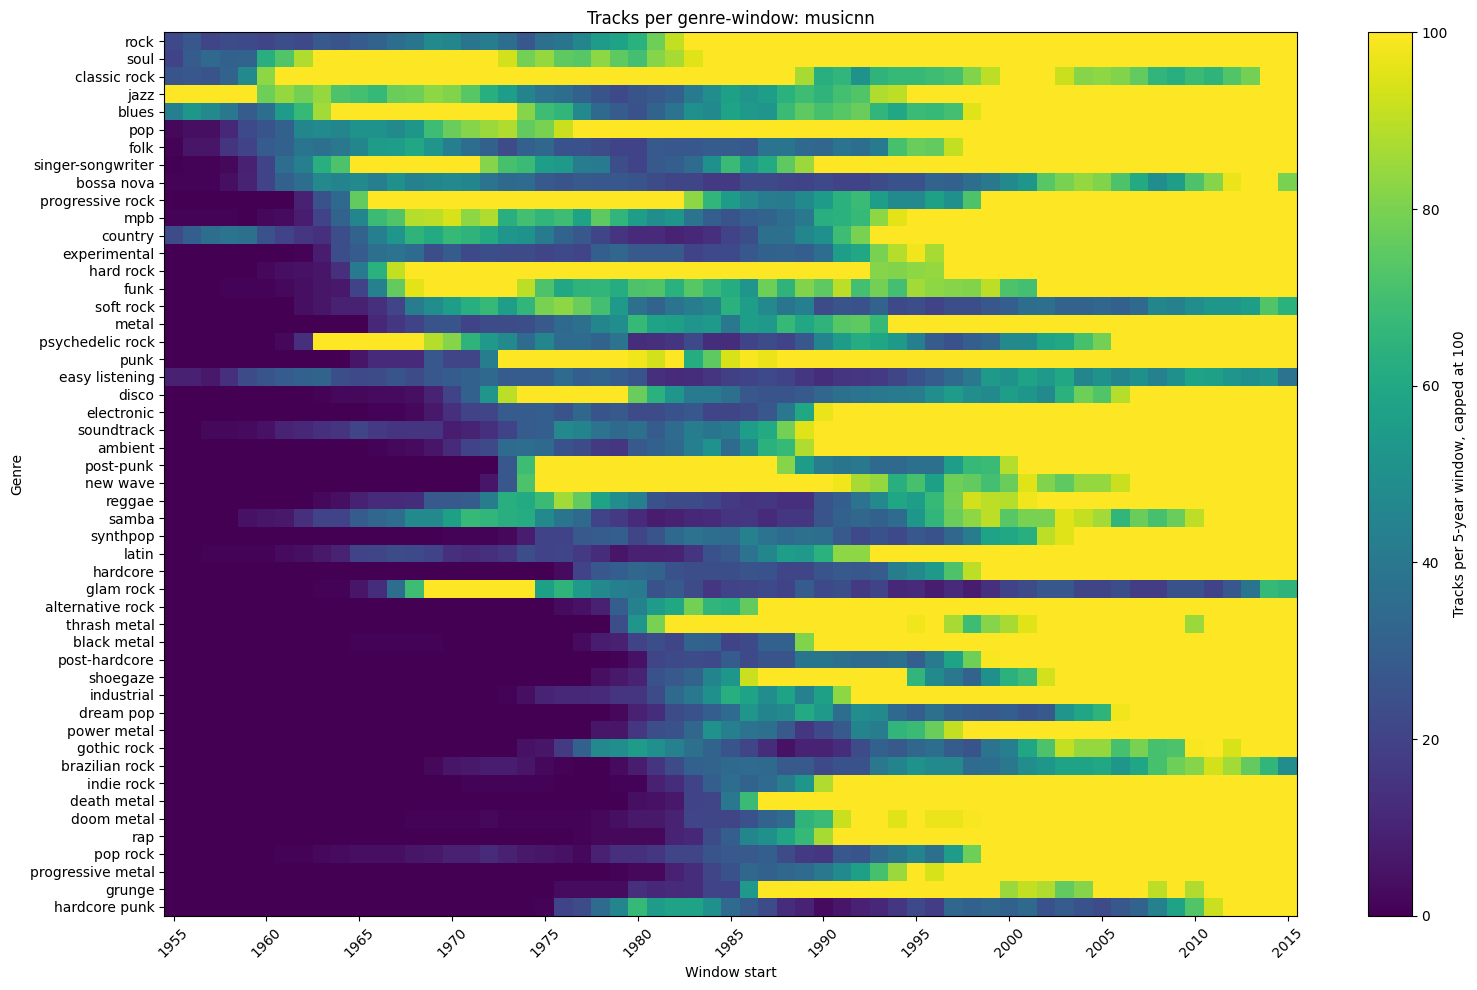

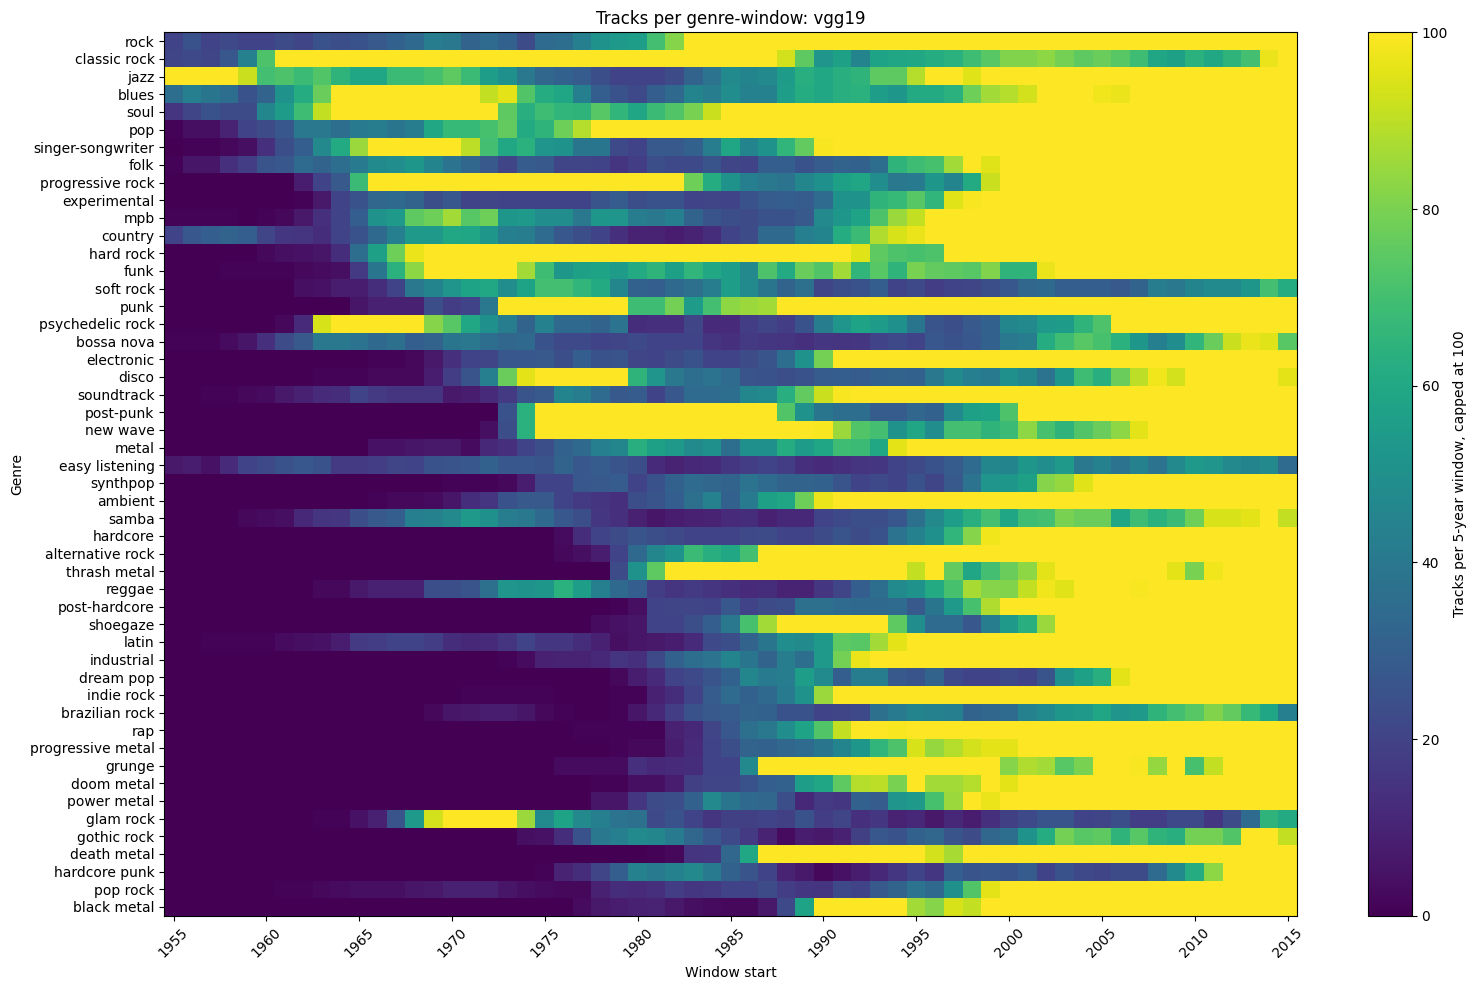

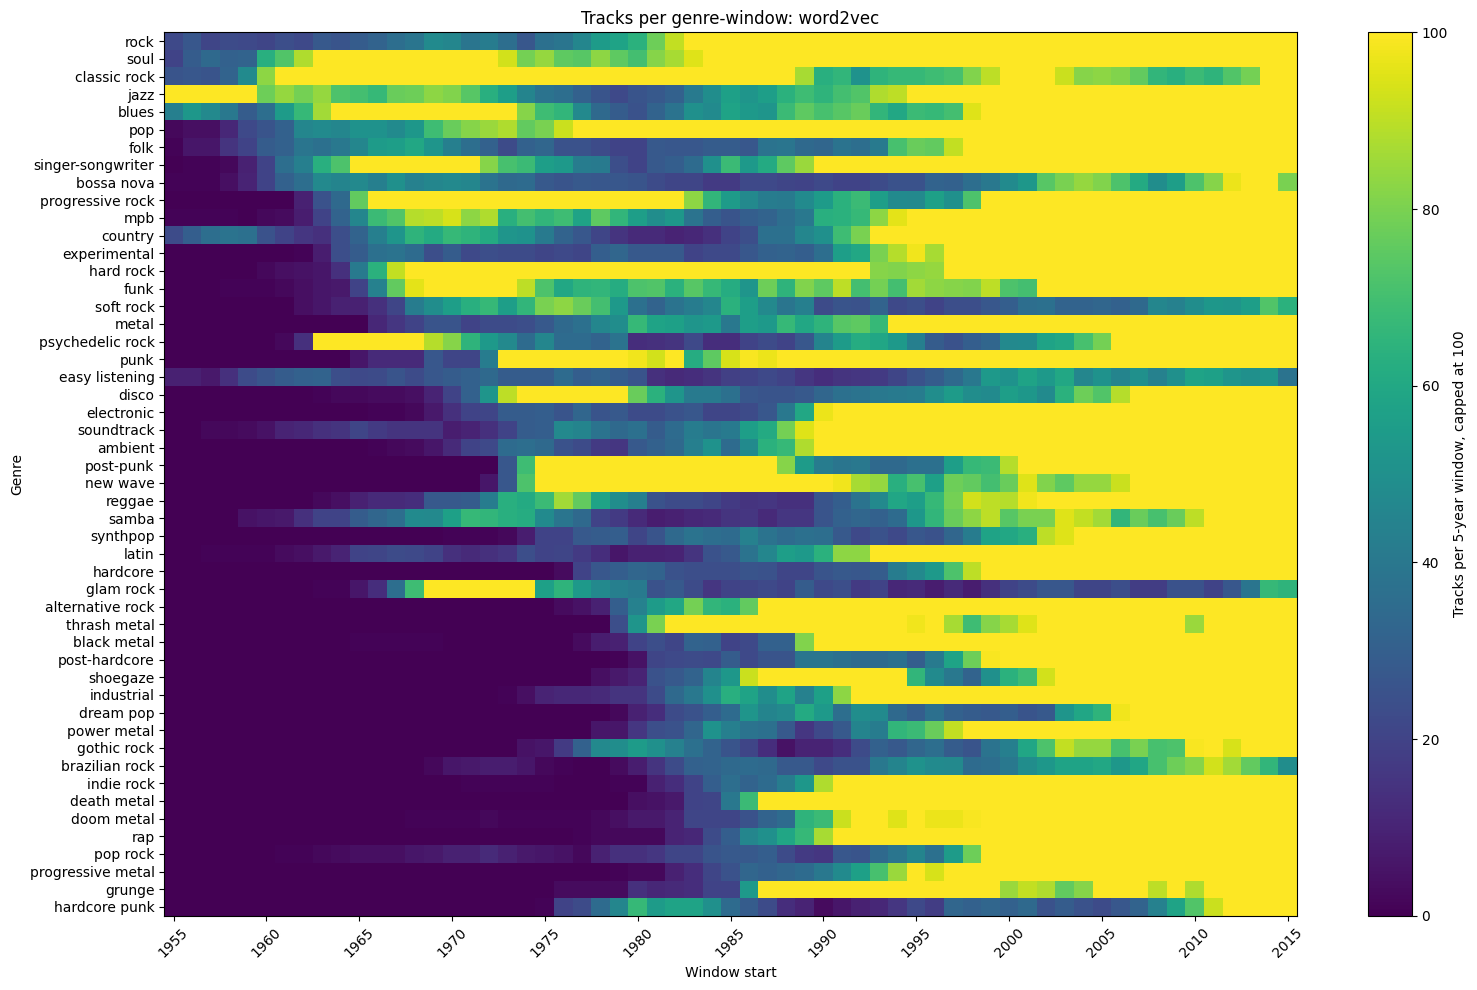

In [45]:
modalities = sorted(genre_window_coverage["modality"].unique())
n_top_genres = 100
max_color_tracks = 100

for selected_modality in modalities:
    modality_genres = genre_window_coverage[
        genre_window_coverage["modality"] == selected_modality
    ].copy()

    top_stable_genres = (
        genre_availability[
            genre_availability["modality"] == selected_modality
        ]
        .sort_values(
            ["n_centroid_eligible_windows", "n_tracks_total"],
            ascending=[False, False]
        )
        .head(n_top_genres)["genre"]
    )

    matrix_data = modality_genres[
        modality_genres["genre"].isin(top_stable_genres)
    ].pivot_table(
        index="genre",
        columns="window_start",
        values="n_tracks",
        aggfunc="sum",
        fill_value=0
    )

    matrix_data = matrix_data.reindex(top_stable_genres)

    plt.figure(figsize=(16, 10))

    plt.imshow(
        matrix_data,
        aspect="auto",
        cmap="viridis",
        vmin=0,
        vmax=max_color_tracks
    )

    plt.yticks(range(len(matrix_data.index)), matrix_data.index)
    plt.xticks(
        range(0, len(matrix_data.columns), 5),
        matrix_data.columns[::5],
        rotation=45
    )

    plt.xlabel("Window start")
    plt.ylabel("Genre")
    plt.title(f"Tracks per genre-window: {selected_modality}")

    cbar = plt.colorbar()
    cbar.set_label(f"Tracks per 5-year window, capped at {max_color_tracks}")

    plt.tight_layout()

    plt.savefig(
        PLOTS_DIR / f"coverage_tracks_per_genre_window_top{n_top_genres}_{selected_modality}_capped{max_color_tracks}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()